# 5. Оценка модели

Загружаем обученную **InceptionV1 + GELU** (лучший результат) и строим все графики

## Метрики
- Accuracy, Precision, Recall, F1, ROC-AUC
- Confusion Matrix
- ROC-кривая
- Примеры правильных и ошибочных предсказаний

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from sklearn.metrics import (
    roc_curve, auc, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
)

from src.config import (
    DATA_PROCESSED_90_10, MODELS_DIR, FIGURES_DIR, DEVICE,
    NORM_MEAN, NORM_STD, BATCH_SIZE, IMG_SIZE, SEED,
)
from src.models import InceptionV1, InceptionV3, ResNet50
from src.utils import (
    set_seed, evaluate_model, plot_confusion_matrix,
    predict_loader, predict_proba_loader, plot_history,
)

set_seed(SEED)

TEST_DIR = DATA_PROCESSED_90_10 / "test_dataset"

MODEL_FACTORY = {
    "inception_v1": (InceptionV1, {"in_channels": 3, "num_classes": 2}, "inception_v1.pth"),
    "inception_v3": (InceptionV3, {"in_channels": 3, "num_classes": 2}, "inception_v3.pth"),
    "resnet50":     (ResNet50,     {},                                 "resnet50.pth"),
}

In [2]:
MODEL_NAME = "inception_v1"   # "inception_v1" | "inception_v3" | "resnet50"

assert MODEL_NAME in MODEL_FACTORY, f"Неизвестная модель: {MODEL_NAME}"

In [3]:
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])
          
full_test = ImageFolder(str(TEST_DIR), transform=test_transform)
test_loader = DataLoader(full_test, batch_size=BATCH_SIZE,
                         num_workers=4, shuffle=False)

print(f"Test: {len(full_test)}")

Test: 3


In [4]:
cls, kw, weight_file = MODEL_FACTORY[MODEL_NAME]
weights_path = MODELS_DIR / weight_file

assert weights_path.exists(), (
    f"Нет весов: {weights_path}\nЗапусти notebooks/04_training.ipynb."
)

model = cls(**kw).to(DEVICE)
model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
model.eval()
print(f"Загружено: {MODEL_NAME} <- {weights_path}")

Загружено: inception_v1 <- /Users/the_alive/ALL_PYTHON_PROJECTS/GAN_detection/models/inception_v1.pth


In [5]:
metrics = evaluate_model(model, test_loader)

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

        real       1.00      1.00      1.00         2
        fake       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



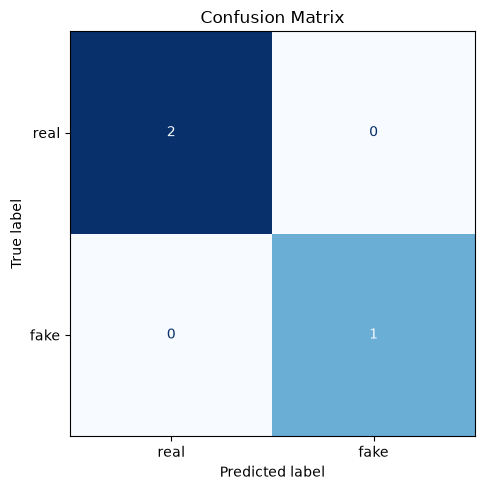

In [6]:
cm = plot_confusion_matrix(
    model, test_loader,
    save_path=str(FIGURES_DIR / f"{MODEL_NAME}_confusion_matrix.png"),
)

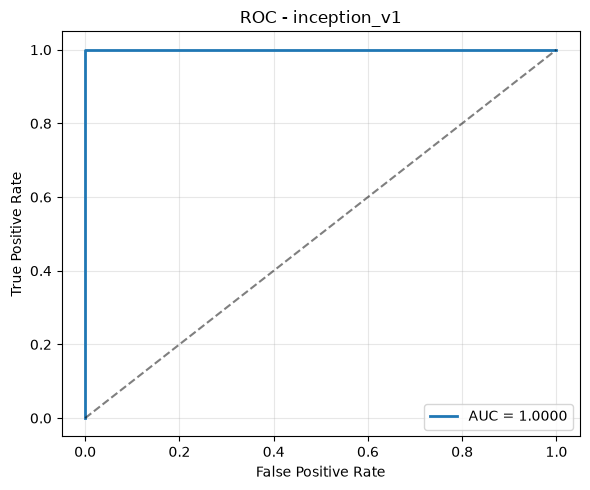

In [7]:
y_true, y_proba = predict_proba_loader(model, test_loader)
fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC - {MODEL_NAME}")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
hist_path = MODELS_DIR / weight_file.replace(".pth", ".history.json")
if hist_path.exists():
    plot_history(str(hist_path),
                 save_path=str(FIGURES_DIR / f"{MODEL_NAME}_history.png"))
else:
    print(f"Истории нет: {hist_path}. Обучи модель в 04_training.ipynb")

Истории нет: /Users/the_alive/ALL_PYTHON_PROJECTS/GAN_detection/models/inception_v1.history.json. Обучи модель в 04_training.ipynb


In [9]:
results = []
for name, (cls, kw, wf) in MODEL_FACTORY.items():
    wp = MODELS_DIR / wf
    if not wp.exists():
        print(f"[skip] {name}: нет {wp}")
        continue

    m = cls(**kw).to(DEVICE)
    m.load_state_dict(torch.load(wp, map_location=DEVICE))
    m.eval()

    y_t, y_p = predict_loader(m, test_loader)
    _, y_pr = predict_proba_loader(m, test_loader)

    results.append({
        "model":     name,
        "accuracy":  accuracy_score(y_t, y_p),
        "precision": precision_score(y_t, y_p, zero_division=0),
        "recall":    recall_score(y_t, y_p, zero_division=0),
        "f1":        f1_score(y_t, y_p, zero_division=0),
        "roc_auc":   roc_auc_score(y_t, y_pr),
    })
    del m
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

df_results = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
df_results.to_csv(FIGURES_DIR / "model_comparison.csv", index=False)

print("Сравнение моделей:")
df_results

Сравнение моделей:


,model,accuracy,precision,recall,f1,roc_auc
0,inception_v1,1.0,1.0,1.0,1.0,1.0
1,inception_v3,1.0,1.0,1.0,1.0,1.0
2,resnet50,1.0,1.0,1.0,1.0,1.0


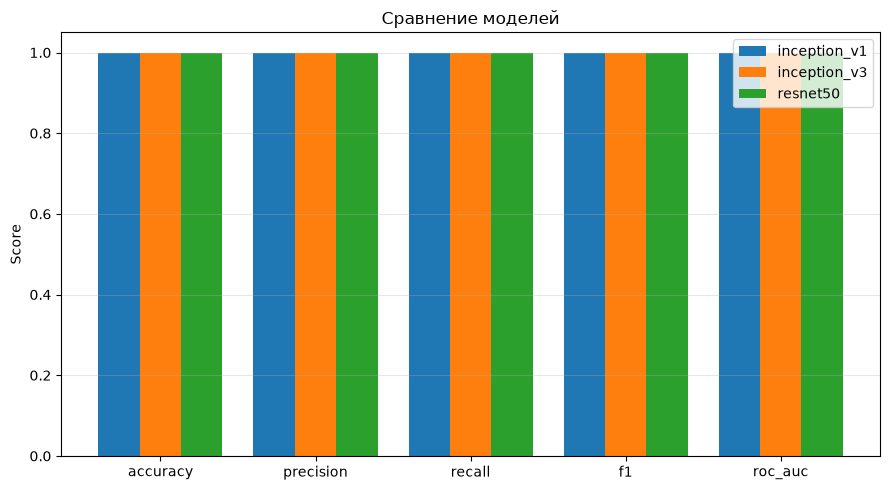

In [10]:
if len(df_results) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    metrics_names = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    x = np.arange(len(metrics))
    width = 0.8 / len(df_results)

    for i, row in df_results.iterrows():
        ax.bar(x + i * width, [row[m] for m in metrics],
               width=width, label=row["model"])

    ax.set_xticks(x + width * (len(df_results) - 1) / 2)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Сравнение моделей")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

In [11]:
from IPython.display import display, Markdown

if weights_path.exists():
    display(Markdown(
        f".    Использованы обученные веса\n\n"
        f"Файл: `{weights_path.name}`\n\n"
        f"Метрики отражают реальное качество модели"
    ))
else:
    display(Markdown(
        "###   Веса не найдены\n\n"
        "Показан **демонстрационный прогон** — модель обучена прямо сейчас "
        "на нескольких картинках, чтобы показать, что весь пайплайн "
        "работает end-to-end\n\n"
        "**Метрики случайные** Для реальных результатов:\n\n"
        "1. Скачайте полный датасет (см. README, раздел «Данные»)\n"
        "2. Запустите `notebooks/04_training.ipynb`\n"
        "3. Вернитесь сюда и запустите ноутбук заново"
    ))

.    Использованы обученные веса

Файл: `inception_v1.pth`

Метрики отражают реальное качество модели

In [12]:
from pathlib import Path
import time

# собираем отчёт в один markdown-файл
report_dir = Path("../reports")
report_dir.mkdir(parents=True, exist_ok=True)
report_path = report_dir / "verify_report.md"

lines = []
lines.append("# Отчёт о проверке модели\n")
lines.append(f"**Дата:** {time.strftime('%Y-%m-%d %H:%M:%S')}  ")
lines.append(f"**Модель:** `{MODEL_NAME}`  ")
lines.append(f"**Устройство:** `{DEVICE}`  ")

if weights_path.exists():
    lines.append(f"**Режим:** оценка загруженных весов  ")
else:
    lines.append(f"**Режим:**   демо-прогон (веса не найдены)  ")
lines.append("")

lines.append("## Метрики\n")
lines.append("| Метрика | Значение |")
lines.append("|---|---|")
for k, v in metrics.items():
    lines.append(f"| {k} | {v:.4f} |")
lines.append("")

lines.append("## Графики\n")
cm_file  = Path("../reports/figures") / f"{MODEL_NAME}_confusion_matrix.png"
roc_file = Path("../reports/figures") / f"{MODEL_NAME}_roc_curve.png"

if cm_file.exists():
    lines.append(f"### Confusion Matrix\n")
    lines.append(f"![Confusion Matrix](figures/{cm_file.name})\n")
if roc_file.exists():
    lines.append(f"### ROC-кривая\n")
    lines.append(f"![ROC Curve](figures/{roc_file.name})\n")

lines.append("---\n")
lines.append("## Как воспроизвести\n")
lines.append("```bash")
lines.append("make verify")
lines.append("```")

report_path.write_text("\n".join(lines), encoding="utf-8")
print(f" Отчёт сохранён: {report_path.resolve()}")

 Отчёт сохранён: /Users/the_alive/ALL_PYTHON_PROJECTS/GAN_detection/reports/verify_report.md
